# `04-agent.ipynb`

- langgraph로 Agent 직접 만들어 보기
- llm에 직접 tool 연결하기


In [5]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
from langchain.tools import tool

@tool
def add(a: int, b: int) -> int:
    '''
    'a'와 'b'를 더한다

    Args:
        a: first int
        b : second int
    '''
    return a + b


@tool
def multiply (a: int, b: int) -> int:
    '''
    'a'와 'b'를 곱한다

    Args:
        a: first int
        b : second int
    '''
    return a * b


@tool
def divide(a: int, b: int) -> float:
    '''
    'a'와 'b'를 나눈다.

    Args:
        a: first int
        b : second int
    '''
    return a / b


tools = [add, multiply, divide]

# add.name , multiply.name, divide.name

# [n+1 for n in [1, 2, 3]]

# { x : 0 for x in ['a', 'b', 'c']}  #  {'a': 0, 'b': 0, 'c': 0}

tools_by_name = {tool.name: tool for tool in tools}
# {tool.name: tool for tool in tools}

{'add': StructuredTool(name='add', description="'a'와 'b'를 더한다\n\nArgs:\n    a: first int\n    b : second int", args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x10ed57b00>),
 'multiply': StructuredTool(name='multiply', description="'a'와 'b'를 곱한다\n\nArgs:\n    a: first int\n    b : second int", args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x10ed57ba0>),
 'divide': StructuredTool(name='divide', description="'a'와 'b'를 나눈다.\n\nArgs:\n    a: first int\n    b : second int", args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x10ed57ce0>)}

tools = [add, multiply, divide]
llm_with_tools = llm.bind_tools(tools)

llm_with_tools.invoke("3 곱하기 4는?")
```

LLM이 내부적으로 받는 정보:
```
너한테는 이런 도구들이 있어:
- add(a, b)      → a와 b를 더함
- multiply(a, b) → a와 b를 곱함  
- divide(a, b)   → a와 b를 나눔

질문: "3 곱하기 4는?"
```

LLM의 응답 (실제 계산 X, **계획만** 세움):
```
→ multiply 도구를 (3, 4)로 호출해야겠다!


 tool_calls=[{'name': 'multiply', 'args': {'a': 4, 'b': 2}, 'id': 'call_Eh1jsJjNUWascrxp42EyvDJu', 'type': 'tool_call'}, 
             {'name': 'divide', 'args': {'a': 10, 'b': 4}, 'id': 'call_SJGBynudFgSzpHmvJGotXf0I', 'type': 'tool_call'}]

In [ ]:
tool_calls=[{'name': 'multiply', 'args': {'a': 4, 'b': 2}, 'id': 'call_Eh1jsJjNUWascrxp42EyvDJu', 'type': 'tool_call'}, 
             {'name': 'divide', 'args': {'a': 10, 'b': 4}, 'id': 'call_SJGBynudFgSzpHmvJGotXf0I', 'type': 'tool_call'}]

In [7]:
from langchain.chat_models import init_chat_model

llm = init_chat_model('gpt-4.1-mini')
llm_with_tools = llm.bind_tools(tools)

# 실행 직전 세팅까지만 함 ->  multiply tool을 (4, 2)로 실행하고, divide를 (10,4)로 실행하면 되겠네라는 생각까지만 했음 (실제 실행 X)
# 어떤 툴에 어떤 인자를 넣을지 까지만 계획함
llm_with_tools.invoke('3 + 4 * 2 - 10 /4')

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 162, 'total_tokens': 212, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_bf4a14fd1f', 'id': 'chatcmpl-DFxKw8v448gX49EqNZud72aSUCki2', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cbce0-e7fc-7710-be67-4bd9b7ae5542-0', tool_calls=[{'name': 'multiply', 'args': {'a': 4, 'b': 2}, 'id': 'call_Eh1jsJjNUWascrxp42EyvDJu', 'type': 'tool_call'}, {'name': 'divide', 'args': {'a': 10, 'b': 4}, 'id': 'call_SJGBynudFgSzpHmvJGotXf0I', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 162, 'output_tokens': 50, 'total_tokens': 212, 'input_token_det

In [ ]:
# 이게 MessageState와 같음

# class Mystate(TypedDict):
#     messages: Annotated[list[Anymessage], add_messages]

#     {messages: [SystemMessage(), HumanMessage(), ToolMessage()]}

#     {
#         'messeages':[
#             SystemMessage(),
#             HumanMessage(),
#             ToolMessage()
#         ]
#     }

class MessagesState(TypedDict):
    messages: Annotated[list, add_messages]  # add_messages가 핵심!
```

`add_messages` 덕분에 반환값이 **덮어쓰기가 아니라 추가**로 동작해요.
```
### 처음 state
messages: [HumanMessage('3 + 4는?')]

#### llm_call 노드 실행 후
messages: [
    HumanMessage('3 + 4는?'),
    AIMessage(tool_calls=[add(3,4)])   # ← 추가됨
]

### tool_node 실행 후
messages: [
    HumanMessage('3 + 4는?'),
    AIMessage(tool_calls=[add(3,4)]),
    ToolMessage('7')                   # ← 추가됨
]

### llm_call 다시 실행 후
messages: [
    HumanMessage('3 + 4는?'),
    AIMessage(tool_calls=[add(3,4)]),
    ToolMessage('7'),
    AIMessage(content='3 + 4는 7입니다!')  # ← 추가됨
]


### tool 써야 할 때
AIMessage(content='', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_abc123'}])

### tool 안 써도 될 때 (일반 대화)
AIMessage(content='3 더하기 4는 7입니다!', tool_calls=[])

In [ ]:
from langgraph.graph import MessagesState
from langchain.messages import SystemMessage, HumanMessage, ToolMessage

from typing import TypedDict, Annotated


# MessagesState -> 매우 기본적인 state 형태. messages만 저장함

# Node

# messages = [HumanMessage(content="Add 3 and 4.")] <-리스트 형식으로 넣어줘야 함 Why? new_messages에서 처리하는건 리스트 + 리스트로 
'''
class MessagesState(TypedDict):
    messages: Annotated[list, add_messages]
'''

def llm_call(state: MessagesState):
    '''LLM이 Tool을 사용할지 안할지 결정'''
    
    new_messages = [
        SystemMessage( '너는 사칙연산을 도와주는 멋진 어시스턴트야.')
    ] + state['messages'] # 첫 시작 시 여기에 HumanMessage() 객체가 추가됨

# [
#     SystemMessage('너는 사칙연산을 도와주는 멋진 어시스턴트야.')
# ] 
# +
# [
#     HumanMessage('1+1은 뭐야?'),
#     AIMessage('2 입니다.'),
#     HumanMessage('1+1은 뭐야?')
#     AIMessage('2라고')
# ]


    # 결과값은 아래와 같이 AIMessage 객체 하나만 나옴 
    
    llm_with_tools.invoke(new_messages)
    '''
    AIMessage(content='',tool_calls=[ {'name': 'add', 'args': {'a': 3, 'b': 4},'id': 'call_abc123'}])

    '''

    result = llm_with_tools.invoke(new_messages)

    return{'messages': result} # <- MessageState 내부 add_messages로 기존 state + AIMessages()
                               # 노드라서 MessageState와 같은 형태를 맞추기 위해 {'messages': } <-이런 형식으로 리턴함

                        # MessageState 에서 'messages': []로 정의해서 당연히 input도 list로 넣어줘야 함
llm_call ( { 'messages': [HumanMessage('1+1이 뭐야?')]})
llm_call ( { 'messages': [HumanMessage('심심해')]})

# 결과값은 return{'messages': result} -> {'messages': AIMessages()}
# 

{'messages': AIMessage(content='심심할 때는 새로운 것을 배우거나 재미있는 이야기를 듣는 것도 좋고, 간단한 게임을 하거나 퀴즈를 풀어보는 것도 좋아요. 어떤 걸 해보고 싶나요? 아니면 제가 사칙연산 문제를 내드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 173, 'total_tokens': 234, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_828130e5d4', 'id': 'chatcmpl-DFxL058PVmGJiShocpVTotUemxWpI', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cbce0-fa15-7511-9ad0-6b266f5a8b53-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 173, 'output_tokens': 61, 'total_tokens': 234, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})}

In [ ]:
# @tool 데코레이터로 감싸면 StructuredTool 객체로 변환

tool = tools_by_name['add']
# tool = StructuredTool(name='add', ...)

tool.invoke({'a': 3, 'b': 4})  # ✅ StructuredTool의 메서드 호출
# → 7

# @tool 데코레이터 때문에 StructuredTool 객체로 바뀌어서 일반 함수 호출 불가
add(3, 4)        # ❌ StructuredTool 객체라 이렇게 못 부름

7

In [ ]:
def tool_node(state: MessagesState):
    '''실제 Tool 호출'''
    result = []

    #  tool_call 형태 -> [ {'name': 'add', 'args': {'a': 3, 'b': 4},'id': 'call_abc123'} , {'name': 'multiply, ~~}]
    
    for tool_call in state['messages'][-1].tool_calls:
        # 실제 Tool 고르기
        tool = tools_by_name[tool_call['name']]
        '''
        {   'add': StructuredTool(name='add', description=''),
            'multiply': StructuredTool(name='multiply', description = '', ),
            'divide': StructuredTool(name='divide', description= ''}
        '''
        # Tool 실행하고 결과 관측
        observation = tool.invoke(tool_call['args'])  # {"a": 1, "b": 1} 
        # 모든 선택된 tool을 호출하고, 결과를 모음
        result.append(ToolMessage(content=observation, tool_call_id=tool_call['id']))

    return {'messages': result}



In [24]:
# llm call 이후에 tool_node를 사용할지, 끝낼지 결정하는 라우터
from typing import Literal 
from langgraph.graph import START, END, StateGraph
from IPython.display import Image, display
def should_continue(state: MessagesState) -> Literal['tool_node', END]:
    ''' 툴 호출할지, 끝낼지를 결정 '''
    last_message = state['messages'][-1]

    if last_message.tool_calls:   # tool_calls 리스트에 내용이 있으면
        return 'tool_node'
    else:
        return END


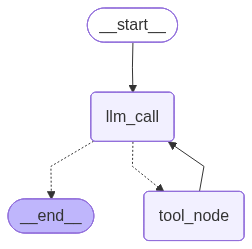

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_R4knjElP9c7bYzXuhy5sujAi)
 Call ID: call_R4knjElP9c7bYzXuhy5sujAi
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

3 더하기 4는 7입니다.


In [25]:
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

In [26]:
messages = [HumanMessage(content=" 3 + 4 * 2 / 3 알려줘")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

 3 + 4 * 2 / 3 알려줘
================================== Ai Message ==================================
Tool Calls:
  multiply (call_sCmCi2mbOX4TTUaQZG6zrIbV)
 Call ID: call_sCmCi2mbOX4TTUaQZG6zrIbV
  Args:
    a: 4
    b: 2
  divide (call_6kXQHQ8eugoLD2pBFaFeqoSS)
 Call ID: call_6kXQHQ8eugoLD2pBFaFeqoSS
  Args:
    a: 8
    b: 3
================================= Tool Message =================================

8
================================= Tool Message =================================

2.6666666666666665
================================== Ai Message ==================================
Tool Calls:
  add (call_icHbJFAuC39jmt9Zw5Rnqren)
 Call ID: call_icHbJFAuC39jmt9Zw5Rnqren
  Args:
    a: 3
    b: 2
================================= Tool Message =================================

5
================================== Ai Message ==================================

3 + 4 * 2 / 3의 계산 결과는 5입니다.
